In [ ]:
!pip install --upgrade --force-reinstall git+https://github.com/CyprienBouton/MRzero-Core.git@T1_T2_variable

# I) Imports

In [1]:
import MRzeroCore as mr0
import pypulseq as pp
import numpy as np
import matplotlib.pyplot as plt
import torch

# II) Load and Build a Dynamic Phantom

In [4]:
# Replace this line with your MRzero parameter file (.npz)
PHANTOM_URL = '../MRXCAT_raw_data/lge/lge__2x2x5mm_128x192x16x32x4_snr30_fa15_bh_phantom.npz'

In [5]:
phantom = mr0.DynamicVoxelPhantom.load(PHANTOM_URL)

VoxelGridPhantom
size = tensor([0.1920, 0.1920, 0.1920])
Plotting 1st of 4 coil sens maps
Plotting slice 8 / 16
Plotting 1st of 32 time frames


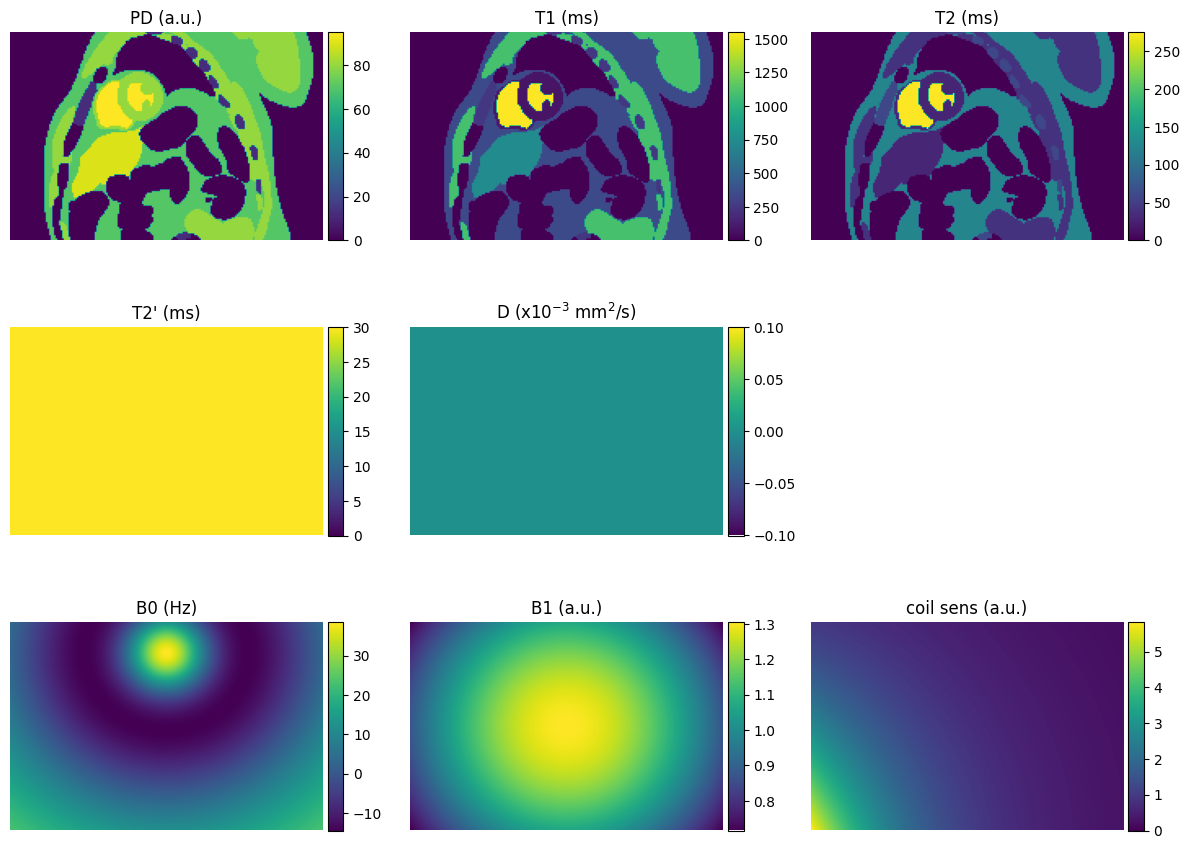

In [6]:
phantom.plot(time_unit='ms', display_units=True)

# III) Create a Segmented Flash 2D Sequence

In [15]:
# Create a sequence object
seq = pp.Sequence()

# System limits
system = pp.Opts()

# Sequence parameters
fov = 200e-3           # Field of view [m]
slice_thickness = 10e-3 # Slice thickness [m]
Nread = 64               # Frequency encoding steps
Nphase = 64               # Phase encoding steps
flip_angle = 15             # Flip angle [deg]
TE = 2e-3            # Echo time [s]
TI = 300e-3            # Inversion time [s]
dwell_time = 2e-5      # Dwell time [s]

# RF pulse and slice-selection gradient
rf_inv = pp.make_block_pulse(flip_angle=180 * np.pi / 180, duration=5e-3, system=system, )
rf_read = pp.make_sinc_pulse(
        flip_angle=flip_angle * np.pi / 180, duration=1e-3,
        slice_thickness=slice_thickness, apodization=0.5, time_bw_product=4,
        system=system, return_gz=False,
)

# Define other gradients and ADC events
gx = pp.make_trapezoid(channel='x', flat_area=Nread/fov, flat_time=Nread*dwell_time, system=system)
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area / 2, duration=1e-3, system=system)
adc = pp.make_adc(num_samples=Nread, duration=Nread*dwell_time, phase_offset=0 * np.pi/180, delay=gx.rise_time, system=system)
gx_spoil = pp.make_trapezoid(channel='x', area=1.5 * gx.area, duration=2e-3, system=system)

# Prephasing gradients
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area/2, duration=1e-3, system=system)

# Phase encoding steps (in y)
all_phenc = np.arange(-Nphase // 2, Nphase // 2, 1) / fov


seq.add_block(rf_inv)
# wait for the inversion time
seq.add_block(pp.make_delay(TI))

for area_ph in all_phenc:
    #
    # Add sequence block
    gy_pre = pp.make_trapezoid(channel='y', area=area_ph, duration=1e-3, system=system)
    gy_post = pp.make_trapezoid(channel='y', area=-gy_pre.area, duration=1e-3, system=system)
    seq.add_block(rf_read)
    seq.add_block(pp.make_delay(TE))
    seq.add_block(gx_pre, gy_pre)
    seq.add_block(gx, adc)
    seq.add_block(gx_spoil, gy_post)
        

seq_file = 'flash2D_ir.seq'
seq.write(seq_file)

'c31a8aaf34c306a174fd287acaa58600'

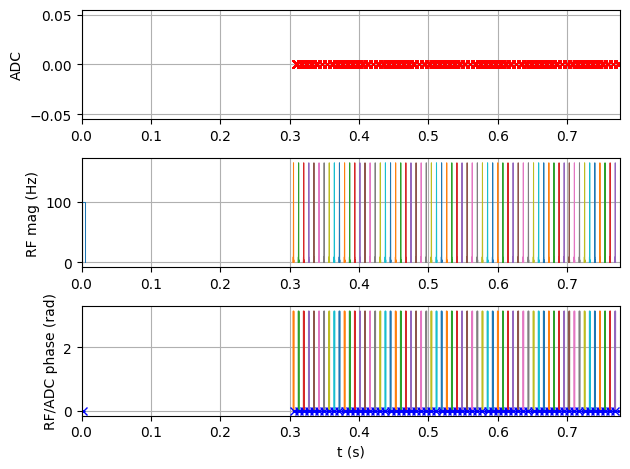

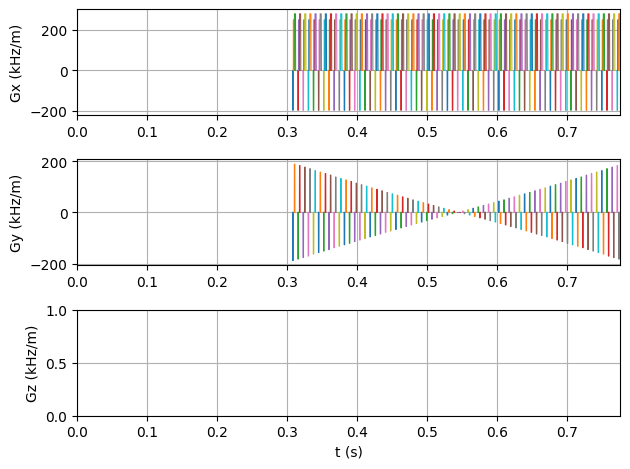

In [16]:
seq.plot()

# III) Simulate and visualize results

In [17]:
seq0 = mr0.Sequence.import_file(seq_file)
rep_times = torch.tensor(np.cumsum([r.event_time.sum() for r in seq0]))

phantom_mid = phantom.slices([phantom.PD.shape[-1]//2])
data = phantom_mid.build(rep_times)
graph = mr0.compute_graph(seq0, data)
sig = mr0.execute_graph(graph, seq0, data)

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000852641 s
Compute Graph
Computing Graph: 0.014311542 s
Analyze Graph
Analyzing Graph: 0.000249853 s
Converting Rust -> Python: 0.006868463 s
<<<< Rust <<<<
Calculating repetition 65 / 65 - done


In [18]:
kspace = torch.reshape((sig), (Nphase, Nread, 4)).clone()

In [19]:
# fftshift
image = torch.fft.fftshift( torch.fft.ifftn( torch.fft.ifftshift(kspace, axis=[0,1]), axis=[0,1] ), axis=[0,1] )
image = torch.sqrt(torch.sum(image**2, -1))

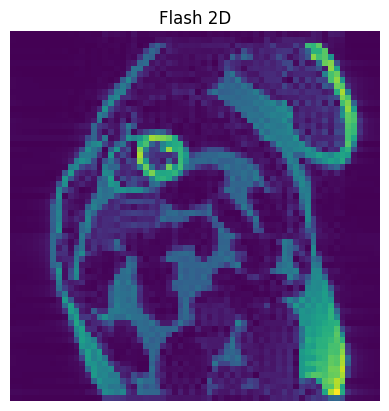

In [20]:
plt.imshow(torch.fliplr(image.abs()))
plt.axis('off')
plt.title('Flash 2D')
plt.show()